# Multi-Asset Portfolio Performance, Risk & Attribution Report

*FINM3422 Assessment 2 — [Group 6 - Yi Chen (Cathy), Caden Rieger, Archer Hanrahan, Sienna Hockaday]*

## 1. Introduction & Methodology

### 1.1 Purpose and Scope

This report analyses the performance, risk, and active-return drivers of a stylised Australian superannuation fund invested across five sleeves: Australian Equities (AUS EQ), International Equities (INTL EQ), Bonds, Real Estate (RE), and Private Equity / Venture Capital (PEVC), over the ten-year period from January 2016 to December 2025. Each sleeve is managed externally and evaluated against a sleeve benchmark, while the total fund is evaluated against an SAA-weighted composite benchmark.

### 1.2 Portfolio Construction

The fund's policy benchmark is constructed using SAA weights, while the implemented portfolio uses Tactical Asset Allocation (TAA) weights. Both weight sets are held constant over the sample period.

| Sleeve | TAA (Portfolio) | SAA (Benchmark) |
|---|---|---|
| AUS EQ | 35% | 40% |
| INTL EQ | 35% | 30% |
| Bonds | 15% | 20% |
| RE | 5% | 5% |
| PEVC | 10% | 5% |

### 1.3 Methodology

All metrics are computed from monthly decimal returns and annualised using the square-root-of-time rule for volatility and geometric compounding for returns.

**Performance and risk metrics.** For each sleeve and the total fund, we compute annualised return, annualised volatility, the Sharpe ratio, the Information Ratio (IR), tracking error (TE), and maximum drawdown (MDD). Returns are annualised geometrically and volatility via the square-root-of-time rule:

$$R_{ann} = \prod_{t=1}^{n}(1+r_t)^{12/n} - 1, \qquad \sigma_{ann} = \sigma_{monthly}\sqrt{12}$$

The Sharpe ratio measures total risk-adjusted excess return, while the Information Ratio measures the efficiency of active management — active return per unit of tracking error:

$$\text{Sharpe} = \frac{R_{ann} - R_{f,ann}}{\sigma_{ann}}, \qquad \text{IR} = \frac{R_P - R_B}{\text{TE}}, \qquad \text{TE} = \sigma(r_P - r_B)\sqrt{12}$$

Maximum drawdown captures the largest peak-to-trough decline in cumulative wealth $W_t = \prod_{s=1}^{t}(1+r_s)$:

$$\text{MDD} = \min_t \frac{W_t - \max_{s \leq t} W_s}{\max_{s \leq t} W_s}$$

**APRA-inspired checks.** The total fund is assessed against four simplified prudential thresholds: a long-run return objective (CPI + 4%), a volatility band, a drawdown limit, and an equity-shock stress scenario. These are educational diagnostics rather than reproductions of actual APRA regulations.

**Brinson attribution.** Active return ($R_P - R_B$) is decomposed at the asset-class level into an allocation effect $A_i = (w_{P,i} - w_{B,i})\,R_{B,i}$, capturing the value added by over- or underweighting each sleeve, and a selection effect $S_i = w_{B,i}(R_{P,i} - R_{B,i})$, capturing manager skill within each sleeve. Effects are computed monthly and aggregated across the sample.

### 1.4 Data and Implementation

The analysis uses the frozen teaching dataset provided in `data/a2_release/`, comprising monthly returns for each manager and benchmark, a monthly risk-free rate proxy, and the SAA weights. All metric and attribution functions are implemented as reusable modules under `src/` (`performance.py`, `apra_checks.py`, `attribution.py`) and called from this notebook to keep the report cell-light and reproducible.

In [25]:
import sys
sys.path.append("../src")  # adjust if your notebook lives elsewhere

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from data_loader import load_all, validate
from performance import all_sleeves_summary

# Load everything
data = load_all(data_dir="../data")  # adjust if needed

managers    = data["managers"]
benchmarks  = data["benchmarks"]
rf          = data["rf"]
taa_weights = data["taa_weights"]
saa_weights = data["saa_weights"]

---

## 2. Data Overview

### 2.1 Source and Structure

The analysis uses the frozen FINM3422 teaching dataset, located at `data/a2_release/`. It comprises five manager return series (`managers/`), five benchmark return series (`benchmarks/`), a monthly risk-free rate proxy (`rf_monthly.csv`), and a Strategic Asset Allocation file (`saa_weight.csv`). All return series are reported as **monthly decimal returns** (e.g. 0.0123 = +1.23%) on month-end dates, and all 11 series share an identical, gap-free `DatetimeIndex`.

Manager returns are **synthetic** (artificially generated for teaching purposes). They are designed to behave realistically, capturing plausible relationships between sleeves, benchmarks, and the risk-free rate, but do not correspond to any real-world fund. This caveat is carried into the limitations discussion in section 7.

In [26]:
# Summary statistics for managers and benchmarks (monthly returns)
summary = pd.concat([
    managers.add_suffix("_mgr"),
    benchmarks.add_suffix("_bm")
], axis=1).describe().T

summary[["count", "mean", "std", "min", "max"]].round(4)

,count,mean,std,min,max
AUS_EQ_mgr,120.0,0.0064,0.0409,-0.1931,0.0867
INTL_EQ_mgr,120.0,0.0127,0.0345,-0.0699,0.0803
BONDS_mgr,120.0,0.0026,0.0129,-0.0308,0.0344
RE_mgr,120.0,0.0101,0.0540,-0.2000,0.1568
PEVC_mgr,120.0,0.0086,0.0313,-0.0626,0.0946
AUS_EQ_bm,120.0,0.0056,0.0391,-0.2118,0.0996
INTL_EQ_bm,120.0,0.0115,0.0336,-0.0736,0.0764
BONDS_bm,120.0,0.0017,0.0138,-0.0359,0.0366
RE_bm,120.0,0.0084,0.0604,-0.3500,0.1429
PEVC_bm,120.0,0.0080,0.0330,-0.0751,0.0889


**Table 2.1. Monthly return summary statistics (Jan 2016 – Dec 2025).** All figures are monthly decimal returns. Manager series suffixed `_mgr`; benchmarks suffixed `_bm`.

In [27]:
validate(data)

────────────────────────────────────────────────────────────
DATA LOADER — SANITY CHECK REPORT
────────────────────────────────────────────────────────────

Observations     : 120 months
Date range       : 2016-01-31 to 2025-12-31
Manager sleeves  : ['AUS_EQ', 'INTL_EQ', 'BONDS', 'RE', 'PEVC']
Benchmark sleeves: ['AUS_EQ', 'INTL_EQ', 'BONDS', 'RE', 'PEVC']

Indices aligned  : YES
Missing values   : 0 (should be 0)

TAA weights sum  : 1.0000 OK
SAA weights sum  : 1.0000 OK
Sleeve names     : CONSISTENT

────────────────────────────────────────────────────────────


All checks pass: 120 aligned monthly observations spanning Jan 2016 to Dec 2025, no missing values, both weight sets sum to 1.0, and sleeve names are consistent across managers, benchmarks, and weight dictionaries.

### 2.2 Load and Validate Data

Before running any analysis, we call `data_loader.validate()` to confirm the loaded dataset meets the required standards: index alignment across managers, benchmarks, and the risk-free rate; absence of missing values; weight-set integrity (TAA and SAA each summing to 1.0); and consistent sleeve naming across all weight-aware objects.

### 2.3 Observations

The dataset spans 120 monthly observations across all 10 series, with no missing values and full index alignment between managers, benchmarks, and the risk-free rate.

A first read of the summary statistics reveals patterns consistent with each asset class's known characteristics:

- **International Equities** generated the highest mean monthly return on both the manager (1.27%) and benchmark (1.15%) sides, with moderate dispersion, suggesting a strong risk/reward profile over the sample.
- **Bonds** exhibited by far the lowest volatility (manager std 1.29%, benchmark std 1.38%) and the tightest min–max range, consistent with their role as the fund's defensive allocation.
- **Real Estate** showed the widest dispersion, with a benchmark minimum of −35.0% in a single month, alongside an outsized maximum of +14.3%. The manager's range was meaningfully tighter (−20.0% to +15.7%), an early indication of downside mitigation that we examine more formally in section 3.
- **Australian Equities** showed a similar pattern, with the manager's worst month (−19.3%) modestly less severe than the benchmark's (−21.2%).
- **PE/VC** manager and benchmark statistics are broadly comparable, with a small mean uplift on the manager side (0.86% vs 0.80% monthly) and similar dispersion.

These descriptive statistics motivate the formal performance, risk, and attribution analysis in the sections that follow, where we annualise these monthly figures and examine each sleeve's behaviour relative to its benchmark.

---

## 3. Sleeve-Level Performance

This section evaluates each of the five sleeves against its benchmark, using the metrics defined in section 1.3. Performance is presented in three layers: a summary table comparing managers across all metrics, individual wealth-index charts showing each manager's path against its benchmark, and a cross-sleeve comparison of Sharpe and Information Ratios.

### 3.1 Summary Metrics

In [28]:
# Manager-level summary across all 5 sleeves
sleeves = list(managers.columns)

mgr_summary = all_sleeves_summary(managers, benchmarks, rf, sleeves)

# Format as percentages where appropriate
mgr_summary.style.format({
    "Ann. Return":       "{:.2%}",
    "Ann. Volatility":   "{:.2%}",
    "Sharpe Ratio":      "{:.3f}",
    "Active Return":     "{:.2%}",
    "Tracking Error":    "{:.2%}",
    "Information Ratio": "{:.3f}",
    "Max Drawdown":      "{:.2%}",
})

,Ann. Return,Ann. Volatility,Sharpe Ratio,Active Return,Tracking Error,Information Ratio,Max Drawdown
Sleeve,,,,,,,
AUS_EQ,6.91%,14.16%,0.273,1.05%,4.40%,0.238,-24.63%
INTL_EQ,15.57%,11.96%,1.048,1.47%,2.57%,0.573,-16.49%
BONDS,3.02%,4.46%,-0.005,1.09%,0.94%,1.165,-11.35%
RE,10.84%,18.72%,0.416,1.98%,7.10%,0.278,-28.69%
PEVC,10.24%,10.86%,0.663,0.72%,2.08%,0.347,-11.62%


**Table 3.1 — Manager performance vs benchmark, by sleeve.** Returns, volatility, tracking error, and drawdown are annualised; Sharpe and Information Ratio are dimensionless.

### 3.2 Cross-Sleeve Comparison

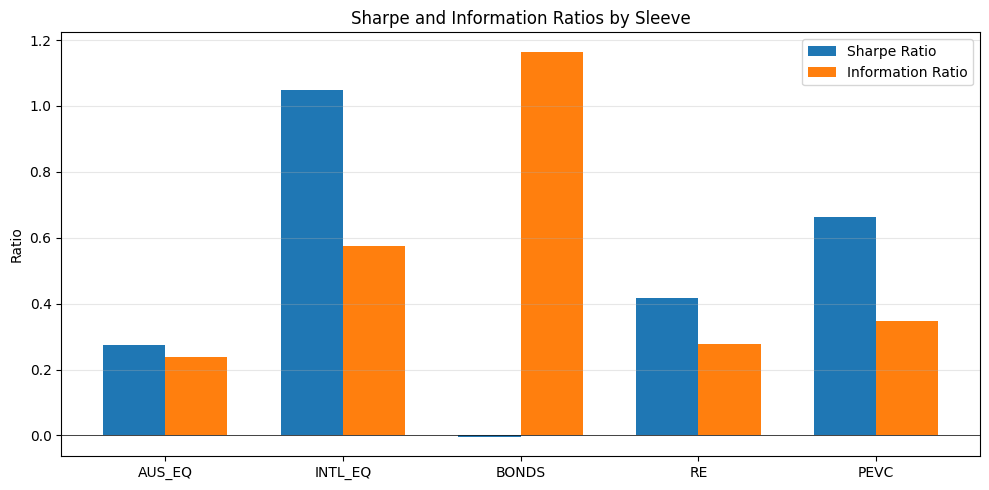

In [29]:
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(sleeves))
width = 0.35

ax.bar(x - width/2, mgr_summary["Sharpe Ratio"],      width, label="Sharpe Ratio")
ax.bar(x + width/2, mgr_summary["Information Ratio"], width, label="Information Ratio")

ax.set_xticks(x)
ax.set_xticklabels(sleeves)
ax.axhline(0, color="black", linewidth=0.5)
ax.set_ylabel("Ratio")
ax.set_title("Sharpe and Information Ratios by Sleeve")
ax.legend()
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

### 3.3 Manager vs Benchmark — Wealth Indices

Each chart below tracks the cumulative wealth of $1 invested at the start of the sample period, comparing the manager's path against the corresponding benchmark.

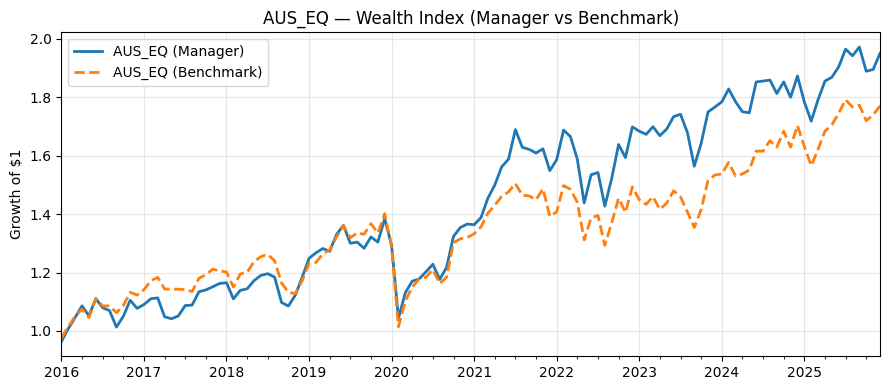

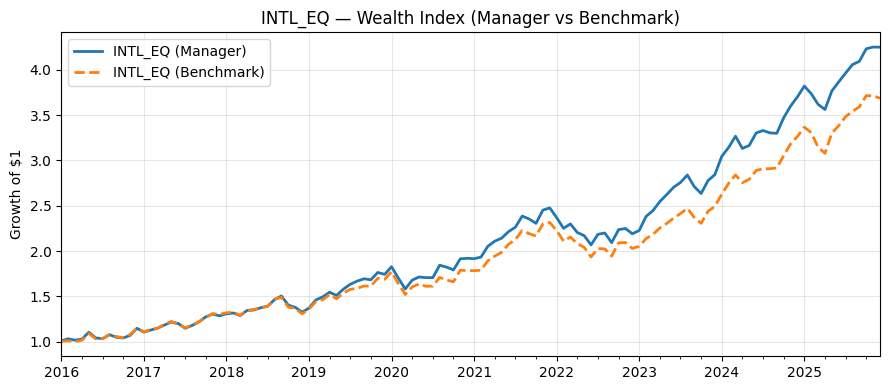

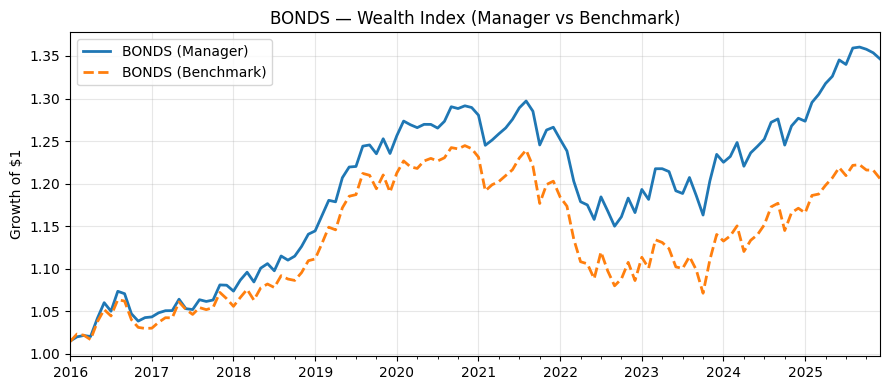

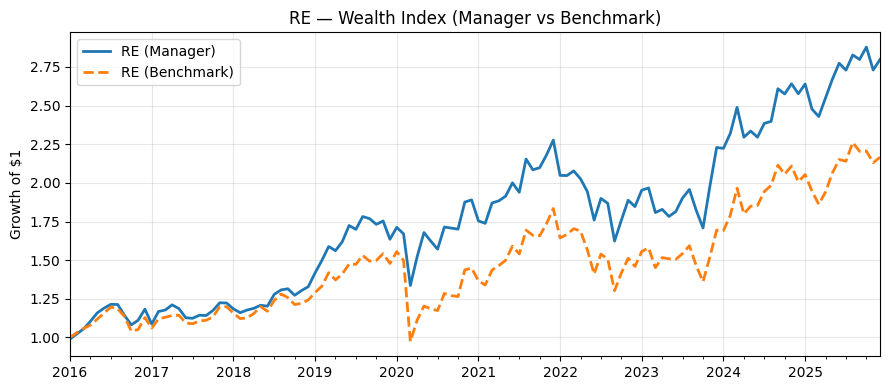

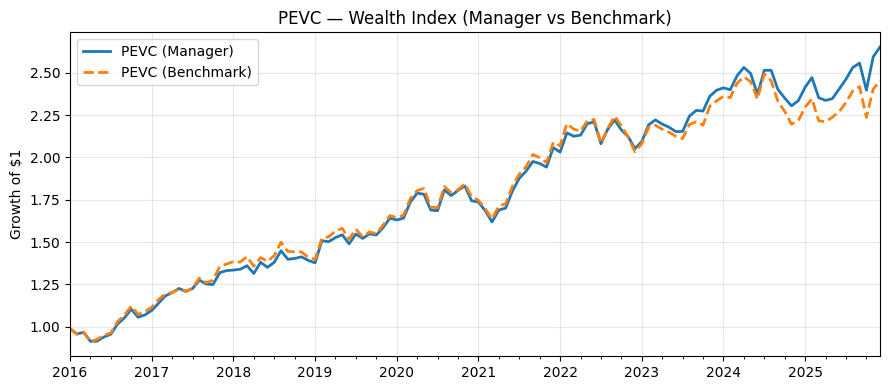

In [30]:
from performance import wealth_index

for sleeve in sleeves:
    fig, ax = plt.subplots(figsize=(9, 4))

    wealth_index(managers[sleeve]).plot(ax=ax, label=f"{sleeve} (Manager)", linewidth=2)
    wealth_index(benchmarks[sleeve]).plot(ax=ax, label=f"{sleeve} (Benchmark)", linewidth=2, linestyle="--")

    ax.set_title(f"{sleeve} — Wealth Index (Manager vs Benchmark)")
    ax.set_ylabel("Growth of $1")
    ax.set_xlabel("")
    ax.legend(loc="best")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

**Figure 3.1 — Sharpe and Information Ratios across sleeves.** Sharpe measures excess return over the risk-free rate per unit of total volatility; Information Ratio measures active return per unit of tracking error.

### 3.4 Discussion



**International Equities is the standout sleeve on every dimension.** It generated the highest annualised return (15.57%), the strongest Sharpe ratio (1.05), and a robust Information Ratio of 0.57, all while running the second-lowest manager volatility (11.96%). This combination of strong absolute and risk-adjusted performance makes it the largest single contributor to fund-level returns over the sample period.

**The Bonds sleeve illustrates why Sharpe and Information Ratio capture different things.** Its Sharpe is effectively zero (−0.005), the bond manager's 3.02% annualised return barely exceeded the risk-free rate over the period, yet it delivered the *highest* Information Ratio of any sleeve (1.17). The interpretation is that the manager added consistent active value relative to the bond benchmark, but the bond asset class itself offered little reward over cash. This is a useful diagnostic: a manager can do their job well even when the asset class disappoints, and a fund relying solely on Sharpe would mis-rank the bond manager's skill.

**Real Estate is the highest-risk sleeve.** It posted the largest tracking error (7.10%), the worst maximum drawdown (−28.69%), and the highest annualised volatility (18.72%). The manager nonetheless generated a respectable 1.98% active return, the largest in absolute terms, but did so by accepting substantially more relative risk than other managers, as reflected in the modest IR of 0.28.

**Australian Equities is the weakest active manager in the equity space.** Despite a similar volatility profile to International Equities, AUS_EQ delivered less than half the annualised return (6.91% vs 15.57%) and a Sharpe of just 0.27. Its IR of 0.24 is also the lowest among the equity-style sleeves, suggesting limited skill relative to the AUS benchmark over the period.

**PE/VC sits in the middle of the pack.** It produced 10.24% return at 10.86% vol, which is the most efficient absolute risk/reward profile after International Equities, but its IR of 0.35 indicates only modest skill relative to its synthetic benchmark.

**Cross-cutting observations.** All five managers beat their benchmarks in active-return terms over the period, but the *quality* of that outperformance varies widely (IRs ranging from 0.24 to 1.17). The fund's largest sleeves by TAA weight (AUS_EQ and INTL_EQ at 35% each) lie at opposite ends of the manager-skill spectrum, which has implications for the attribution analysis in section 6 — selection effects from these two sleeves will likely dominate the active-return decomposition.